(a) Rows remaining after removing failed transactions: 8

(b) Cleaned transaction data:
   txn_id customer   txn_date     category  amount   status    month
0       1       c1 2026-01-03  electronics  1000.0  Success  2026-01
1       2       c2 2026-01-15      grocery   300.0  Success  2026-01
3       4       c3 2026-02-02      fashion   800.0  Success  2026-02
4       5       c2 2026-02-10      grocery   450.0     None  2026-02
5       6       c1 2026-02-25      fashion     NaN  Success  2026-02
7       8       c3 2026-03-12      grocery   250.0     None  2026-03
8       9       c2 2026-03-18      fashion  -100.0  Success  2026-03
9      10       c1 2026-03-28  electronics     NaN     None  2026-03

(c) Per-customer summary:
          net_amount  txns  refunds
customer                           
c1            1000.0     3        0
c2             650.0     3        0
c3            1050.0     2        0

(d) Monthly totals by category:
category  electronics  fashion  grocery
month      

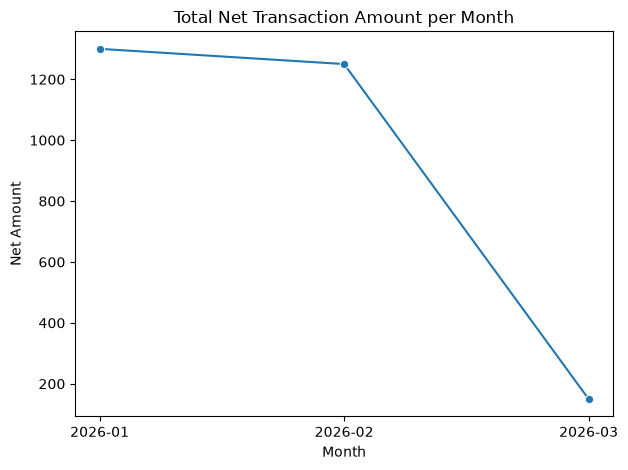

In [3]:
# c2 answer 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the transaction DataFrame. The first 10 statuses align with txn_id 1-10.
txn = pd.DataFrame({
    "txn_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "customer": ["c1", "c2", "c1", "c3", "c2", "c1", "c3", "c3", "c2", "c1"],
    "txn_date": [
        "2026-01-03", "2026-01-15", "2026-01-20", "2026-02-02", "2026-02-10",
        "2026-02-25", "2026-03-05", "2026-03-12", "2026-03-18", "2026-03-28",
    ],
    "category": [
        "electronics", " grocery ", "GROCERY", "Fashion", "grocery",
        "fashion", "Grocery", "grocery", "Fashion", "Electronics",
    ],
    "amount": [1000, 300, np.nan, 800, 450, np.nan, 400, 250, -100, np.nan],
    "status": [
        "Success", "Success", "Failed", "Success", None,
        "Success", "Failed", None, "Success", None,
    ],
})

# Part (a): Remove failed transactions and report how many rows remain.
txn = txn.loc[txn["status"].ne("Failed")].copy()
print("(a) Rows remaining after removing failed transactions:", len(txn))

# Part (b): Clean categories, convert txn_date to datetime, and add YYYY-MM month.
txn["category"] = txn["category"].str.strip().str.lower()
txn["txn_date"] = pd.to_datetime(txn["txn_date"])
txn["month"] = txn["txn_date"].dt.strftime("%Y-%m")
print("\n(b) Cleaned transaction data:")
print(txn)

# Part (c): Summarize net amount, transaction count, and refund rows per customer.
customer_summary = txn.groupby("customer").agg(
    net_amount=("amount", "sum"),
    txns=("txn_id", "count"),
    refunds=("status", lambda status: status.eq("Refund").sum()),
)
print("\n(c) Per-customer summary:")
print(customer_summary)

# Part (d): Pivot total amount by month and category; fill missing values with 0.
monthly_category_totals = txn.pivot_table(
    index="month",
    columns="category",
    values="amount",
    aggfunc="sum",
    fill_value=0,
)
print("\n(d) Monthly totals by category:")
print(monthly_category_totals)

# Part (e): Plot total net amount per month as a Seaborn line plot.
monthly_net = txn.groupby("month", as_index=False)["amount"].sum()
monthly_net = monthly_net.rename(columns={"amount": "net_amount"})
print("\n(e) Total net amount per month:")
print(monthly_net)

sns.lineplot(data=monthly_net, x="month", y="net_amount", marker="o")
plt.title("Total Net Transaction Amount per Month")
plt.xlabel("Month")
plt.ylabel("Net Amount")
plt.tight_layout()
plt.show()
